# Functions needed for research

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import struct

CAMERA_MODELS = {
    0: ("SIMPLE_PINHOLE", 3), # f, cx, cy
    1: ("PINHOLE", 4),        # fx, fy, cx, cy (Undistortion 후 주로 사용됨)
    2: ("SIMPLE_RADIAL", 4),  # f, cx, cy, k
    3: ("RADIAL", 5),         # f, cx, cy, k1, k2
    4: ("OPENCV", 8),         # fx, fy, cx, cy, k1, k2, p1, p2 (기존 모델)
    5: ("OPENCV_FISHEYE", 8), 
    6: ("FULL_OPENCV", 12)
}

def readCamerasBin(file_path):
    cameras = {}
    with open(file_path, "rb") as fid:
        # 1. 카메라 개수 읽기
        num_cameras = struct.unpack("<Q", fid.read(8))[0]
        
        for _ in range(num_cameras):
            # 2. Camera ID, Model ID
            camera_id = struct.unpack("<I", fid.read(4))[0]
            model_id = struct.unpack("<I", fid.read(4))[0]
            
            # 3. Width, Height
            width = struct.unpack("<Q", fid.read(8))[0]
            height = struct.unpack("<Q", fid.read(8))[0]
            
            # 4. Model ID에 따라 파라미터 개수를 동적으로 결정
            if model_id not in CAMERA_MODELS:
                raise ValueError(f"지원하지 않는 카메라 모델 ID입니다: {model_id}")
            
            model_name, num_params = CAMERA_MODELS[model_id]
            
            # 5. Parameters 읽기
            params = struct.unpack("<" + "d" * num_params, fid.read(8 * num_params))
            
            cameras[camera_id] = {
                "model_name": model_name,
                "model_id": model_id,
                "width": width,
                "height": height,
                "params": params
            }
    return cameras

def readColmapImagesBin(file_path):
    images = {}
    
    with open(file_path, "rb") as fid:
        # The first 8 bytes contain the total number of images
        numRegImages = struct.unpack("<Q", fid.read(8))[0]
        
        for _ in range(numRegImages):
            # Read fixed-length camera pose and IDs (64 bytes total)
            # i = int (4 bytes), d = double (8 bytes)
            binaryImageProperties = struct.unpack("<idddddddi", fid.read(64))
            
            imageId = binaryImageProperties[0]
            qvec = np.array(binaryImageProperties[1:5])  # Quaternion (w, x, y, z)
            tvec = np.array(binaryImageProperties[5:8])  # Translation (x, y, z)
            cameraId = binaryImageProperties[8]
            
            # Read variable-length image name (stops at null byte \x00)
            imageName = b""
            char = fid.read(1)
            while char != b"\x00":
                imageName += char
                char = fid.read(1)
            imageName = imageName.decode("utf-8")
            
            # Read the number of 2D points for this specific image
            numPoints2D = struct.unpack("<Q", fid.read(8))[0]
            
            # Read 2D points: x (double), y (double), point3D_id (uint64/long long)
            # Each point is 24 bytes (8 + 8 + 8)
            x_y_id_s = struct.unpack("<" + "ddq" * numPoints2D, fid.read(24 * numPoints2D))
            
            # Reconstruct arrays for X,Y coordinates and their 3D point IDs
            if numPoints2D > 0:
                xys = np.column_stack([tuple(x_y_id_s[0::3]), tuple(x_y_id_s[1::3])])
                point3DIds = np.array(tuple(x_y_id_s[2::3]))
                valid_mask = point3DIds != -1
                xys_valid = xys[valid_mask]
                point3DIds_valid = point3DIds[valid_mask]
            else:
                xys = np.empty((0, 2), dtype=np.float64)
                point3DIds = np.empty(0, dtype=np.uint64)
            
            # Store cleanly in a dictionary
            images[imageId] = {
                "id": imageId,
                "name": imageName,
                "camera_id": cameraId,
                "qvec": qvec,
                "tvec": tvec,
                "xys": xys,
                "point3D_ids": point3DIds,
                "xys_valid": xys_valid,
                "point3D_ids_valid": point3DIds_valid
            }
            
    return images


def readColmapPoints3DBin(file_path):
    points3D = {}
    
    with open(file_path, "rb") as fid:
        # 1. Read the total number of 3D points in the file (8 bytes)
        num_points = struct.unpack("<Q", fid.read(8))[0]
        
        for _ in range(num_points):
            # 2. Read the fixed-length properties for one 3D point (51 bytes total)
            # Q = Point ID (8 bytes)
            # ddd = X, Y, Z coordinates (24 bytes)
            # BBB = R, G, B colors (3 bytes)
            # d = Reprojection error (8 bytes)
            # Q = Track length / number of images seeing this point (8 bytes)
            binaryData = fid.read(51)
            unpackedData = struct.unpack("<QdddBBBdQ", binaryData)
            
            point3D_id = unpackedData[0]
            xyz = np.array(unpackedData[1:4])       # The 3D position
            rgb = np.array(unpackedData[4:7])       # The color (0-255)
            error = unpackedData[7]                 # How accurate the point is
            trackLength = unpackedData[8]          # How many images see it
            
            # 3. Read the variable-length "Track" data
            # Each element in the track contains an Image ID (4 bytes) and a 2D Point Index (4 bytes)
            trackBytes = fid.read(8 * trackLength)
            
            if trackLength > 0:
                # Unpack all track integers at once using 'i' (4-byte integer)
                trackData = struct.unpack("<" + "ii" * trackLength, trackBytes)
                
                # Slice the tuple: evens are Image IDs, odds are Point2D Indexes
                imageIds = np.array(trackData[0::2])
                point2DIdxs = np.array(trackData[1::2])
            else:
                imageIds = np.array([], dtype=np.int32)
                point2DIdxs = np.array([], dtype=np.int32)
            
            # 4. Store everything cleanly in the dictionary
            points3D[point3D_id] = {
                "id": point3D_id,
                "xyz": xyz,
                "rgb": rgb,
                "error": error,
                "image_ids": imageIds,
                "point2D_idxs": point2DIdxs
            }
            
    return points3D



# Running convert.py

We will run the following terminal command:

```cmd
python convert.py -s Gaussiatest/Test
```

Here this command assumes there already have been input images in [`GaussianTest/Test/input`](GaussianTest/Test/input)


참고:
* windows: folder/files folder\files 둘 다 인식
* Unix 계열: linux, mac OS, foler/files

#### Check images:

In [2]:
inputdir = Path("GaussianTest/Test2/input")
for file in list(inputdir.iterdir()):
    print(file)

GaussianTest\Test2\input\0001.jpg
GaussianTest\Test2\input\0002.jpg
GaussianTest\Test2\input\0003.jpg
GaussianTest\Test2\input\0004.jpg
GaussianTest\Test2\input\0005.jpg
GaussianTest\Test2\input\0006.jpg
GaussianTest\Test2\input\0007.jpg
GaussianTest\Test2\input\0008.jpg
GaussianTest\Test2\input\0009.jpg
GaussianTest\Test2\input\0010.jpg
GaussianTest\Test2\input\0011.jpg
GaussianTest\Test2\input\0012.jpg
GaussianTest\Test2\input\0013.jpg
GaussianTest\Test2\input\0014.jpg
GaussianTest\Test2\input\0015.jpg
GaussianTest\Test2\input\0016.jpg
GaussianTest\Test2\input\0017.jpg
GaussianTest\Test2\input\0018.jpg
GaussianTest\Test2\input\0019.jpg
GaussianTest\Test2\input\0020.jpg
GaussianTest\Test2\input\0021.jpg
GaussianTest\Test2\input\0022.jpg
GaussianTest\Test2\input\0023.jpg
GaussianTest\Test2\input\0024.jpg
GaussianTest\Test2\input\0025.jpg
GaussianTest\Test2\input\0026.jpg
GaussianTest\Test2\input\0027.jpg
GaussianTest\Test2\input\0028.jpg


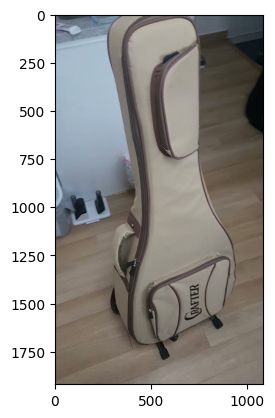

In [3]:
idx = 1 # Change it from 1 to 113
img = plt.imread(inputdir / f"{idx:04d}.jpg")
plt.imshow(img);


# Output Specifics

convert.py의 output은 중간에 COLMAP의 Mapper가 만드는 cameras, images, points3D.bin 파일들이 있고 이는

./GaussianTest/Test/distorted/sparse/0

위 경로에 저장된다.

그리고 Image Undistorter가 만드는 cameras, images, points3D.bin 파일들이 있는데 이는

./GaussianTest/Test/sparse/0

위 경로에 저장된다.

## cameras.bin 비교

### cameras.bin (After Mapper)

In [4]:
f_path = './GaussianTest/Test2/distorted/sparse/0/cameras.bin'
cameraData = readCamerasBin(f_path)
print("model_name:", cameraData[1]["model_name"], "\n")
# print("model_id: ")
# print(cameraData[1]["model_id"], "\n")
print("width:", cameraData[1]["width"], "\n")
print("height:", cameraData[1]["height"], "\n")
print("params:", cameraData[1]["params"], "\n")

model_name: OPENCV 

width: 1080 

height: 1920 

params: (1673.7926122386516, 1677.3664884119826, 540.0, 960.0, 0.04640574850143589, -0.00038629650490264124, -0.009841470471559649, 0.0041267427414467045) 



Mapper는 OPENCV라는 카메라 모델을 사용하였다.  
사용한 이미지의 width(가로 길이)가 1080, height(세로 길이)가 1920임을 알 수 있다.  

카메라의 파라미터로는 순서대로  
Focal Length를 나타내는 $f_x, f_y$  
Principal Point를 나타내는 $c_x, c_y$  
Radial Distortion을 나타내는 $k_1, k_2$  
Tangential Distortion을 나타내는 $p_1, p_2$  
가 있다.

### cameras.bin (After Image Undistorter)

In [5]:
f_path = './GaussianTest/Test2/sparse/0/cameras.bin'
cameraData = readCamerasBin(f_path)
print("model_name:", cameraData[1]["model_name"], "\n")
# print("model_id: ")
# print(cameraData[1]["model_id"], "\n")
print("width:", cameraData[1]["width"], "\n")
print("height:", cameraData[1]["height"], "\n")
print("params:", cameraData[1]["params"], "\n")

model_name: PINHOLE 

width: 1041 

height: 1846 

params: (1673.7926122386516, 1677.3664884119826, 520.5, 923.0) 



Image Undistorter는 PINHOLE이라는 카메라 모델을 쓴다.  
왜곡이 보정되어 width와 height의 값이 달라진 것을 확인할 수 있다.  

카메라 파라미터로 순서대로  
Focal Length를 나타내는 $f_x, f_y$  
Principal Point를 나타내는 $c_x, c_y$  
가 있는데 이는 왜곡을 보정한 뒤이므로 왜곡을 저장했던 파라미터들이 사라졌기 때문이다.

### 사진 비교

위 사진(input)의 width가 아래 사진(After Undistortion)보다 큰 것을 볼 수 있다.

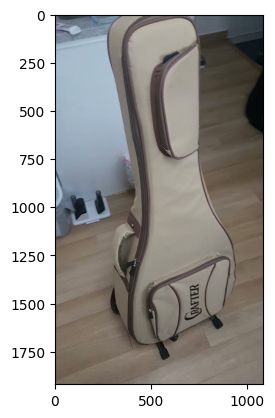

In [6]:
inputdir = Path("GaussianTest/Test2/input")
idx = 1 # Change it from 1 to 28
img = plt.imread(inputdir / f"{idx:04d}.jpg")
plt.imshow(img);

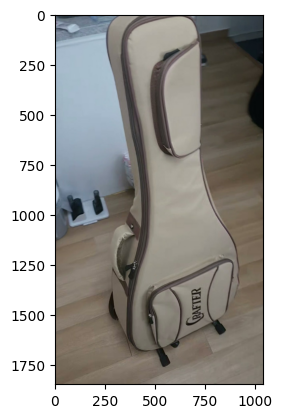

In [7]:
inputdir = Path("GaussianTest/Test2/images")
idx = 1 # Change it from 1 to 28
img = plt.imread(inputdir / f"{idx:04d}.jpg")
plt.imshow(img);

## images.bin 비교

#### How to get data:  

f_path = './GaussianTest/Test2/distorted/sparse/0/images.bin' (DO NOT CHANGE)  
imgData = readColmapImagesBin(f_path)  
  
Example: Print data for the first image  
first_image_id = list(imgData.keys())[0]  
print(imgData[first_image_id]['name'])  
print(imgData[first_image_id]['qvec'])

### images.bin 내용(After Mapper)

In [16]:
f_path = './GaussianTest/Test2/distorted/sparse/0/images.bin'
imgData = readColmapImagesBin(f_path)
imgId = list(imgData.keys())[0]
#print the data of the image
print("name: ", imgData[imgId]['name'])
print("camera_id: ", imgData[imgId]['camera_id'], "\n")
print("qvec: ", imgData[imgId]['qvec'], "\n")
print("tvec: ", imgData[imgId]['tvec'], "\n")
print("xys(feature points): ")
print(imgData[imgId]['xys'], "\n")
print("Number of feature points: ", len(imgData[imgId]['xys']), "\n")
print("Number of valid feature points: ", len(imgData[imgId]['xys_valid']), "\n")
print("xys_valid: \n", imgData[imgId]['xys_valid'], "\n")
print("point3D_ids: ", imgData[imgId]['point3D_ids'], "\n")
print("point3D_ids_valid: \n", imgData[imgId]['point3D_ids_valid'], "\n")

name:  0001.jpg
camera_id:  1 

qvec:  [ 0.98821532 -0.00190512  0.07622084  0.13272993] 

tvec:  [-0.21135841 -3.46193705  2.75338573] 

xys(feature points): 
[[ 191.53845215   15.9071579 ]
 [ 723.39367676   57.0906868 ]
 [ 129.11950684   92.3783493 ]
 ...
 [ 183.76550293 1325.32751465]
 [ 654.31970215  938.73620605]
 [ 654.31970215  938.73620605]] 

Number of feature points:  2115 

Number of valid feature points:  128 

xys_valid: 
 [[ 374.27313232 1150.60131836]
 [ 902.2354126  1273.39050293]
 [ 488.86016846 1538.84643555]
 [ 399.88531494 1726.20605469]
 [ 404.23526001 1743.4675293 ]
 [ 561.78759766  691.21020508]
 [ 370.54302979 1148.4432373 ]
 [ 355.24484253 1150.22924805]
 [ 366.66088867 1155.25537109]
 [ 410.4630127  1309.68371582]
 [ 352.36776733 1340.71716309]
 [ 702.89477539 1438.19226074]
 [ 502.30285645 1524.94213867]
 [ 502.30285645 1524.94213867]
 [ 505.78826904 1540.15100098]
 [ 505.12609863 1544.53405762]
 [ 689.68994141 1551.65917969]
 [ 689.68994141 1551.65917969]
 [

### images.bin 내용(After Image Undistortion)

In [15]:
f_path = './GaussianTest/Test2/sparse/0/images.bin'
imgData = readColmapImagesBin(f_path)
imgId = list(imgData.keys())[0]
# print the data of the image
print("name: ", imgData[imgId]['name'])
print("camera_id: ", imgData[imgId]['camera_id'])
print("qvec: ", imgData[imgId]['qvec'], "\n")
print("tvec: ", imgData[imgId]['tvec'], "\n")
print("xys(feature points): ")
print(imgData[imgId]['xys'], "\n")
print("Number of feature points: ", len(imgData[imgId]['xys']), "\n")
print("Number of valid feature points: ", len(imgData[imgId]['xys_valid']), "\n")
print("xys_valid: \n", imgData[imgId]['xys_valid'], "\n")
print("point3D_ids: ", imgData[imgId]['point3D_ids'], "\n")
print("point3D_ids_valid: \n", imgData[imgId]['point3D_ids_valid'], "\n")


name:  0001.jpg
camera_id:  1
qvec:  [ 0.98821532 -0.00190512  0.07622084  0.13272993] 

tvec:  [-0.21135841 -3.46193705  2.75338573] 

xys(feature points): 
[[ 178.17584732    7.21783012]
 [ 697.61872921   46.12435468]
 [ 116.48467186   79.34114548]
 ...
 [ 162.99888681 1290.51032121]
 [ 634.66835044  901.8375305 ]
 [ 634.66835044  901.8375305 ]] 

Number of feature points:  2115 

Number of valid feature points:  128 

xys_valid: 
 [[ 354.28205816 1114.36240543]
 [ 881.49408031 1237.1475943 ]
 [ 468.44665764 1504.69837055]
 [ 378.93204532 1692.52713659]
 [ 383.25055344 1709.74407535]
 [ 542.01596312  655.81440758]
 [ 350.54580297 1112.19988056]
 [ 335.20280373 1114.02482794]
 [ 346.64019783 1119.05571503]
 [ 390.29926091 1274.36846852]
 [ 331.96474287 1305.71121725]
 [ 682.86133913 1402.98655168]
 [ 481.94951077 1490.70279313]
 [ 481.94951077 1490.70279313]
 [ 485.40198325 1505.96474493]
 [ 484.72720236 1510.36646679]
 [ 669.27811174 1516.89355445]
 [ 669.27811174 1516.89355445]
 [ 7

### 분석

images.bin 파일은 처음 8byte에 전체 이미지 개수를 나타내는 Header가 있다.  
Header(8bytes): 전체 이미지 개수  

그 후 각 이미지당 다음과 같은 데이터를 가진다.
처음에 이미지 데이터 블록이 있는데, 이미지의 고정 속성을 나타낸다.  
**Image Data Block(64 bytes): imageId(int 1개) + qvec(double 3개) + tvec(double 3개) + cameraId(int 1개)**

그리고 이미지 파일 이름이 있다.  
**imageName(changeable)**

그 후 2D 포인트의 개수가 저장되어 있고,  
**numPoints2D(8bytes, double)**

마지막으로 특징점 리스트가 있는데 이는 특징점 개수에 따라 달라진다. 각 데이터는 24 bytes의 크기를 가진다. 이미지 왼쪽 상단 꼭짓점을 기준으로 2차원 좌표계를 만들어 표현한다.(x 좌표는 오른쪽으로 y 좌표는 아래로 +)    
**xys + points3D: x-coord(8bytes, double) + y-coord(8bytes, double) + points3D(8bytes, long long int)**  

두 images.bin의 xys의 결과가 다른 것은 왜곡 보정이 있었기 때문이다.

## points3D.bin 비교

#### How to get data(ex.)

file_path = './GaussianTest/Test/sparse/0/points3D.bin'  
points_data = read_colmap_points3D_bin(file_path)  
  
Example: Get the XYZ coordinate of the first point in the dictionary  
first_point_id = list(points_data.keys())[0]  
print("XYZ:", points_data[first_point_id]['xyz'])  
print("RGB:", points_data[first_point_id]['rgb'])

### points3D.bin 내용(After Mapper)

In [3]:
f_path = './GaussianTest/Test2/distorted/sparse/0/points3D.bin'
pts3DData = readColmapPoints3DBin(f_path)
point3DId = list(pts3DData.keys())[5]
# print the data of the 3D point
print("id: ", pts3DData[point3DId]['id'])
print("xyz: ", pts3DData[point3DId]['xyz'], "\n")
print("rgb: ", pts3DData[point3DId]['rgb'], "\n")
print("error: ", pts3DData[point3DId]['error'], "\n")
print("track length: ", len(pts3DData[point3DId]['image_ids']), "\n")
print("image_ids: ", pts3DData[point3DId]['image_ids'], "\n")
print("point2D_idxs: ", pts3DData[point3DId]['point2D_idxs'], "\n")

id:  3
xyz:  [ 4.49602054 -1.9404369   8.77144024] 

rgb:  [108 102 106] 

error:  0.35603963302085345 

track length:  2 

image_ids:  [27 23] 

point2D_idxs:  [2785 2195] 



### points3D.bin 내용(After Image Undistortion)

In [4]:
f_path = './GaussianTest/Test2/sparse/0/points3D.bin'
pts3DData = readColmapPoints3DBin(f_path)
point3DId = list(pts3DData.keys())[5]
# print the data of the 3D point
print("id: ", pts3DData[point3DId]['id'])
print("xyz: ", pts3DData[point3DId]['xyz'], "\n")
print("rgb: ", pts3DData[point3DId]['rgb'], "\n")
print("error: ", pts3DData[point3DId]['error'], "\n")
print("track length: ", len(pts3DData[point3DId]['image_ids']), "\n")
print("image_ids: ", pts3DData[point3DId]['image_ids'], "\n")
print("point2D_idxs: ", pts3DData[point3DId]['point2D_idxs'], "\n")
    

id:  3
xyz:  [ 4.49602054 -1.9404369   8.77144024] 

rgb:  [108 102 106] 

error:  0.35603963302085345 

track length:  2 

image_ids:  [27 23] 

point2D_idxs:  [2785 2195] 



### 분석

point3D.bin 파일은 images.bin 파일과 마찬가지로 가장 처음 8byte에 이미지의 총 개수가 저장되어 있다.  
Header(8bytes): 전체 이미지 개수  

하나의 3D 포인트는 총 51bytes의 데이터로 이루어져 있고 아래 순서대로 데이터가 저장된다.  
Point ID (8 bytes, long long int)  
X, Y, Z coordinates (24 bytes, double)  
R, G, B colors (3 bytes, 8-bit-unsigned char)  
Reprojection Error (8 bytes, double)  
Track Length: 해당 점을 관측한 이미지의 개수(8 bytes, long long int)

이 뒤에 Track Byte 데이터가 저장되어 있는데 이는 (8*Track Length) byte에 해당하는 크기를 가진다.
(imageId, point2D_idx) 형태의 튜플로 데이터가 저장되어 있다.  
imageId(4bytes, int)
point2D_idx(4bytes, int)  

위 결과를 예시로 들면 __("point3DId = list(pts3DData.keys())[0]")__  
1번 3D point는 27번 사진의 207번 점과 23번 사진의 1079번 점이 교차하여 생성된 3D 점인 것을 알 수 있다.

# 장기적 TODO:

* 본인이 찍은 기타 사진
  * 작은 image set으로 추려서 로컬에서 실행
  * image set 전체 세라프 실행
* gaussian splatting에 많이 쓰이는 공개 image set도 세라프로 실행
* 공개된 set, 본인이 찍은 set 양쪽 다 3dGS계열 최신 논문 찾아서 설치해서 실행해서 비교해보기